# Objetivo 5 — Analisis Ablativo del Circuito Cuantico
Analiza el impacto de los factores de diseno del VQC sobre el rendimiento en imagen pulmonar.  
**Variables ablativas (segun PPI):**
- Numero de qubits: 4, 6, 8
- Profundidad del circuito: 1, 2, 3 capas
- Topologia de entrelazamiento: lineal, circular, full
- Esquema de codificacion: angle encoding (RX / RY) vs amplitude encoding

**Modelo base:** HQCINN (Akpinar et al., 2025) — permite variar todos los factores libremente.
> Ejecutar tras completar el Objetivo 4.

## 0 · Imports y configuracion

In [1]:
import os,random,time,json
from pathlib import Path
from itertools import product
import numpy as np,pandas as pd
import matplotlib.pyplot as plt,seaborn as sns
import torch,torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18,ResNet18_Weights
from torch.utils.data import DataLoader,WeightedRandomSampler
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score,accuracy_score,recall_score,confusion_matrix,roc_auc_score
from sklearn.model_selection import StratifiedKFold
from scipy import stats
SEED=42
random.seed(SEED);np.random.seed(SEED)
torch.manual_seed(SEED);torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark=True;torch.backends.cudnn.deterministic=False
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DEVICE.type=='cuda'
print('Device:',DEVICE,'|',torch.cuda.get_device_name(0))


Device: cuda | NVIDIA GeForce RTX 5060 Laptop GPU


## 1 · Rutas y DataLoaders

In [2]:
BASE_DIR=Path(os.getcwd())
CHEST_OUT=BASE_DIR/'etl_output'/'chest_xray'
LUNG_OUT=BASE_DIR/'etl_output'/'lung_cancer'
IMG_SIZE=(128,128);MEAN=[0.485,0.456,0.406];STD=[0.229,0.224,0.225]
tfm_tr=T.Compose([T.Resize(IMG_SIZE),T.Grayscale(num_output_channels=3),T.RandomRotation(10),T.RandomHorizontalFlip(),T.ColorJitter(brightness=0.15),T.RandomAffine(degrees=0,scale=(0.90,1.10)),T.ToTensor(),T.Normalize(MEAN,STD)])
tfm_ev=T.Compose([T.Resize(IMG_SIZE),T.Grayscale(num_output_channels=3),T.ToTensor(),T.Normalize(MEAN,STD)])
def make_loaders(root,bs=16,weighted=False):
    root=Path(root)
    ds_tr=ImageFolder(root/'train',transform=tfm_tr)
    ds_va=ImageFolder(root/'val',transform=tfm_ev)
    ds_te=ImageFolder(root/'test',transform=tfm_ev)
    kw=dict(num_workers=4,pin_memory=True,persistent_workers=True)
    if weighted:
        tgts=torch.tensor(ds_tr.targets)
        sw=(1.0/torch.bincount(tgts).float())[tgts]
        ltr=DataLoader(ds_tr,batch_size=bs,sampler=WeightedRandomSampler(sw,len(sw),True),**kw)
    else: ltr=DataLoader(ds_tr,batch_size=bs,shuffle=True,**kw)
    return ltr,DataLoader(ds_va,bs,False,**kw),DataLoader(ds_te,bs,False,**kw),ds_tr.class_to_idx
def get_cw(root):
    ds=ImageFolder(Path(root)/'train'); tgts=torch.tensor(ds.targets)
    cw=(1.0/torch.bincount(tgts).float()); return (cw/cw.sum()).to(DEVICE)
chest_cw=get_cw(CHEST_OUT); lung_cw=get_cw(LUNG_OUT)
CHEST_NAMES=['NORMAL','PNEUMONIA']; LUNG_NAMES=['Benign','Malignant','Normal']
print('DataLoaders listos.')


DataLoaders listos.


## 2 · Arquitectura HQCINN configurable
Permite variar qubits, capas, entrelazamiento y encoding.

In [3]:
def get_qdev(n):
    try: return qml.device('lightning.qubit',wires=n)
    except: return qml.device('default.qubit',wires=n)

def build_ablative_hqcinn(nc,n_qubits,n_layers,entanglement='linear',encoding='angle_rx'):
    """
    nc: numero de clases
    n_qubits: 4, 6 u 8
    n_layers: 1, 2 o 3
    entanglement: 'linear' | 'circular' | 'full'
    encoding: 'angle_rx' | 'angle_ry' | 'amplitude'
    """
    dev=get_qdev(n_qubits)
    def entangle_fn(wires,et):
        n=len(wires)
        if et=='linear':    [qml.CNOT(wires=[wires[i],wires[i+1]]) for i in range(n-1)]
        elif et=='circular':[qml.CNOT(wires=[wires[i],wires[(i+1)%n]]) for i in range(n)]
        elif et=='full':    [qml.CNOT(wires=[wires[i],wires[j]]) for i in range(n) for j in range(i+1,n)]

    @qml.qnode(dev,interface='torch',diff_method='adjoint')
    def circuit(inputs,weights_rx,weights_ry,weights_rz):
        # Encoding
        if encoding=='amplitude':
            # Amplitude encoding: normalizar y embeder en amplitudes
            norm=inputs/torch.norm(inputs,dim=-1,keepdim=True).clamp(min=1e-8)
            qml.AmplitudeEmbedding(norm,wires=range(n_qubits),normalize=True,pad_with=0.0)
        elif encoding=='angle_ry':
            qml.AngleEmbedding(inputs,wires=range(n_qubits),rotation='Y')
        else:  # angle_rx
            qml.AngleEmbedding(inputs,wires=range(n_qubits),rotation='X')
        # Capas variacionales
        for l in range(n_layers):
            for q in range(n_qubits):
                qml.RX(weights_rx[l,q],wires=q)
                qml.RY(weights_ry[l,q],wires=q)
                qml.RZ(weights_rz[l,q],wires=q)
            entangle_fn(list(range(n_qubits)),entanglement)
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    ws={k:(n_layers,n_qubits) for k in ['weights_rx','weights_ry','weights_rz']}

    class AblativeHQCINN(nn.Module):
        def __init__(self):
            super().__init__()
            # Para amplitude encoding necesitamos 2^n_qubits features en el input
            input_dim=2**n_qubits if encoding=='amplitude' else n_qubits
            self.feat=nn.Sequential(nn.Conv2d(3,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),nn.AdaptiveAvgPool2d((2,2)))
            self.pre_q=nn.Sequential(nn.Linear(128*2*2,input_dim),nn.Tanh())
            self.ql=TorchLayer(circuit,ws)
            self.cls=nn.Linear(n_qubits,nc)
        def forward(self,x):
            dv=x.device; x=self.feat(x).flatten(1)
            qi=self.pre_q(x).float().cpu()*torch.pi
            return self.cls(self.ql(qi).to(dv).to(x.dtype))

    return AblativeHQCINN()

print('Modelo ablativo definido.')
print('Configuraciones disponibles:')
print('  n_qubits:     4, 6, 8')
print('  n_layers:     1, 2, 3')
print('  entanglement: linear, circular, full')
print('  encoding:     angle_rx, angle_ry, amplitude')


Modelo ablativo definido.
Configuraciones disponibles:
  n_qubits:     4, 6, 8
  n_layers:     1, 2, 3
  entanglement: linear, circular, full
  encoding:     angle_rx, angle_ry, amplitude


## 3 · Funcion de entrenamiento rapido (early stopping patience=3 para ablativo)

In [4]:
def train_ablative(model,tr_l,va_l,cw=None,max_ep=30,patience=3):
    model=model.to(DEVICE)
    crit=nn.CrossEntropyLoss(weight=cw)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    sch=torch.optim.lr_scheduler.MultiStepLR(opt,milestones=[10],gamma=0.1)
    scaler=torch.amp.GradScaler('cuda')
    best_f1,no_imp=0.0,0; best_state=None
    for ep in range(1,max_ep+1):
        model.train();tloss=0.0
        for imgs,lbls in tr_l:
            imgs,lbls=imgs.to(DEVICE,non_blocking=True),lbls.to(DEVICE,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'): logits=model(imgs)
            loss=crit(logits.float(),lbls)
            scaler.scale(loss).backward();scaler.step(opt);scaler.update()
        sch.step()
        model.eval();preds,labs=[],[]
        with torch.no_grad():
            for imgs,lbls in va_l:
                with torch.amp.autocast('cuda'): logits=model(imgs.to(DEVICE,non_blocking=True))
                preds.extend(logits.argmax(1).cpu().numpy()); labs.extend(lbls.numpy())
        f1=f1_score(labs,preds,average='macro',zero_division=0)
        if f1>best_f1: best_f1,no_imp,best_state=f1,0,{k:v.clone() for k,v in model.state_dict().items()}
        else:
            no_imp+=1
            if no_imp>=patience: break
    if best_state: model.load_state_dict(best_state)
    return model,best_f1

def eval_ablative(model,te_l,nc):
    model=model.to(DEVICE).eval()
    preds,labs,probs=[],[],[]
    with torch.no_grad():
        for imgs,lbls in te_l:
            with torch.amp.autocast('cuda'): logits=model(imgs.to(DEVICE,non_blocking=True))
            probs.extend(torch.softmax(logits.float(),1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().numpy()); labs.extend(lbls.numpy())
    acc=accuracy_score(labs,preds)
    f1m=f1_score(labs,preds,average='macro',zero_division=0)
    try: auc=roc_auc_score(labs,probs,multi_class='ovr',average='macro') if nc>2 else roc_auc_score(labs,[p[1] for p in probs])
    except: auc=float('nan')
    return acc,f1m,auc

print('Funciones ablativas listas.')


Funciones ablativas listas.


## 4 · Experimento 1 — Numero de qubits (4, 6, 8)
Entrelazamiento lineal, angle_rx, 1 capa. Dataset: Chest X-Ray.

In [5]:
tr_c,va_c,te_c,_=make_loaders(CHEST_OUT,bs=16,weighted=True)
tr_l,va_l,te_l,_=make_loaders(LUNG_OUT,bs=16,weighted=True)

rows_qubits=[]
for nq in [4,6,8]:
    for ds_name,tr,va,te,nc,cw in [('chest',tr_c,va_c,te_c,2,chest_cw),('lung',tr_l,va_l,te_l,3,lung_cw)]:
        print(f'  qubits={nq} | {ds_name}')
        try:
            m=build_ablative_hqcinn(nc,nq,1,'linear','angle_rx')
            m,_=train_ablative(m,tr,va,cw=cw)
            acc,f1,auc=eval_ablative(m,te,nc)
            rows_qubits.append({'n_qubits':nq,'dataset':ds_name,'Accuracy':round(acc,4),'F1-macro':round(f1,4),'AUC':round(auc,4)})
            del m;torch.cuda.empty_cache()
        except Exception as e: print(f'  Error: {e}'); rows_qubits.append({'n_qubits':nq,'dataset':ds_name,'Accuracy':None,'F1-macro':None,'AUC':None})

df_qubits=pd.DataFrame(rows_qubits)
print('\n=== Resultados: n_qubits ===')
print(df_qubits.to_string())
df_qubits.to_csv(BASE_DIR/'ablativo_qubits.csv',index=False)


  qubits=4 | chest
  qubits=4 | lung
  qubits=6 | chest
  qubits=6 | lung
  qubits=8 | chest
  qubits=8 | lung

=== Resultados: n_qubits ===
   n_qubits dataset  Accuracy  F1-macro     AUC
0         4   chest    0.8783    0.8534  0.9343
1         4    lung    0.1091    0.0656  0.5997
2         6   chest    0.9352    0.9160  0.9676
3         6    lung    0.1091    0.0656  0.4493
4         8   chest    0.9135    0.8976  0.9824
5         8    lung    0.1091    0.0656  0.5191


## 5 · Experimento 2 — Profundidad del circuito (1, 2, 3 capas)
4 qubits, entrelazamiento lineal, angle_rx.

In [6]:
rows_depth=[]
for nl in [1,2,3]:
    for ds_name,tr,va,te,nc,cw in [('chest',tr_c,va_c,te_c,2,chest_cw),('lung',tr_l,va_l,te_l,3,lung_cw)]:
        print(f'  layers={nl} | {ds_name}')
        try:
            m=build_ablative_hqcinn(nc,4,nl,'linear','angle_rx')
            m,_=train_ablative(m,tr,va,cw=cw)
            acc,f1,auc=eval_ablative(m,te,nc)
            rows_depth.append({'n_layers':nl,'dataset':ds_name,'Accuracy':round(acc,4),'F1-macro':round(f1,4),'AUC':round(auc,4)})
            del m;torch.cuda.empty_cache()
        except Exception as e: print(f'  Error: {e}'); rows_depth.append({'n_layers':nl,'dataset':ds_name,'Accuracy':None,'F1-macro':None,'AUC':None})

df_depth=pd.DataFrame(rows_depth)
print('\n=== Resultados: profundidad ===')
print(df_depth.to_string())
df_depth.to_csv(BASE_DIR/'ablativo_profundidad.csv',index=False)


  layers=1 | chest
  layers=1 | lung
  layers=2 | chest
  layers=2 | lung
  layers=3 | chest
  layers=3 | lung

=== Resultados: profundidad ===
   n_layers dataset  Accuracy  F1-macro     AUC
0         1   chest    0.9101    0.8892  0.9589
1         1    lung    0.1091    0.0656  0.5285
2         2   chest    0.9363    0.9191  0.9742
3         2    lung    0.1091    0.0659  0.3581
4         3   chest    0.9067    0.8893  0.9748
5         3    lung    0.1091    0.0656  0.5965


## 6 · Experimento 3 — Topologia de entrelazamiento (lineal, circular, full)
4 qubits, 1 capa, angle_rx.

In [7]:
rows_ent=[]
for ent in ['linear','circular','full']:
    for ds_name,tr,va,te,nc,cw in [('chest',tr_c,va_c,te_c,2,chest_cw),('lung',tr_l,va_l,te_l,3,lung_cw)]:
        print(f'  entanglement={ent} | {ds_name}')
        try:
            m=build_ablative_hqcinn(nc,4,1,ent,'angle_rx')
            m,_=train_ablative(m,tr,va,cw=cw)
            acc,f1,auc=eval_ablative(m,te,nc)
            rows_ent.append({'entanglement':ent,'dataset':ds_name,'Accuracy':round(acc,4),'F1-macro':round(f1,4),'AUC':round(auc,4)})
            del m;torch.cuda.empty_cache()
        except Exception as e: print(f'  Error: {e}'); rows_ent.append({'entanglement':ent,'dataset':ds_name,'Accuracy':None,'F1-macro':None,'AUC':None})

df_ent=pd.DataFrame(rows_ent)
print('\n=== Resultados: entrelazamiento ===')
print(df_ent.to_string())
df_ent.to_csv(BASE_DIR/'ablativo_entrelazamiento.csv',index=False)


  entanglement=linear | chest
  entanglement=linear | lung
  entanglement=circular | chest
  entanglement=circular | lung
  entanglement=full | chest
  entanglement=full | lung

=== Resultados: entrelazamiento ===
  entanglement dataset  Accuracy  F1-macro     AUC
0       linear   chest    0.9238    0.9067  0.9760
1       linear    lung    0.1273    0.0974  0.4967
2     circular   chest    0.9352    0.9206  0.9818
3     circular    lung    0.2970    0.2477  0.5402
4         full   chest    0.8771    0.8563  0.9444
5         full    lung    0.1758    0.1462  0.5177


## 7 · Experimento 4 — Esquema de codificacion (angle_rx, angle_ry, amplitude)
4 qubits, 1 capa, entrelazamiento lineal.

In [8]:
rows_enc=[]
for enc in ['angle_rx','angle_ry','amplitude']:
    for ds_name,tr,va,te,nc,cw in [('chest',tr_c,va_c,te_c,2,chest_cw),('lung',tr_l,va_l,te_l,3,lung_cw)]:
        print(f'  encoding={enc} | {ds_name}')
        try:
            m=build_ablative_hqcinn(nc,4,1,'linear',enc)
            m,_=train_ablative(m,tr,va,cw=cw)
            acc,f1,auc=eval_ablative(m,te,nc)
            rows_enc.append({'encoding':enc,'dataset':ds_name,'Accuracy':round(acc,4),'F1-macro':round(f1,4),'AUC':round(auc,4)})
            del m;torch.cuda.empty_cache()
        except Exception as e: print(f'  Error: {e}'); rows_enc.append({'encoding':enc,'dataset':ds_name,'Accuracy':None,'F1-macro':None,'AUC':None})

df_enc=pd.DataFrame(rows_enc)
print('\n=== Resultados: encoding ===')
print(df_enc.to_string())
df_enc.to_csv(BASE_DIR/'ablativo_encoding.csv',index=False)


  encoding=angle_rx | chest
  encoding=angle_rx | lung
  encoding=angle_ry | chest
  encoding=angle_ry | lung
  encoding=amplitude | chest
  encoding=amplitude | lung

=== Resultados: encoding ===
    encoding dataset  Accuracy  F1-macro     AUC
0   angle_rx   chest    0.9283    0.9123  0.9755
1   angle_rx    lung    0.1091    0.0656  0.5236
2   angle_ry   chest    0.9454    0.9305  0.9752
3   angle_ry    lung    0.1091    0.0674  0.5691
4  amplitude   chest    0.8191    0.8021  0.9447
5  amplitude    lung    0.1091    0.0656  0.6186


## 8 · Visualizacion comparativa de todos los experimentos

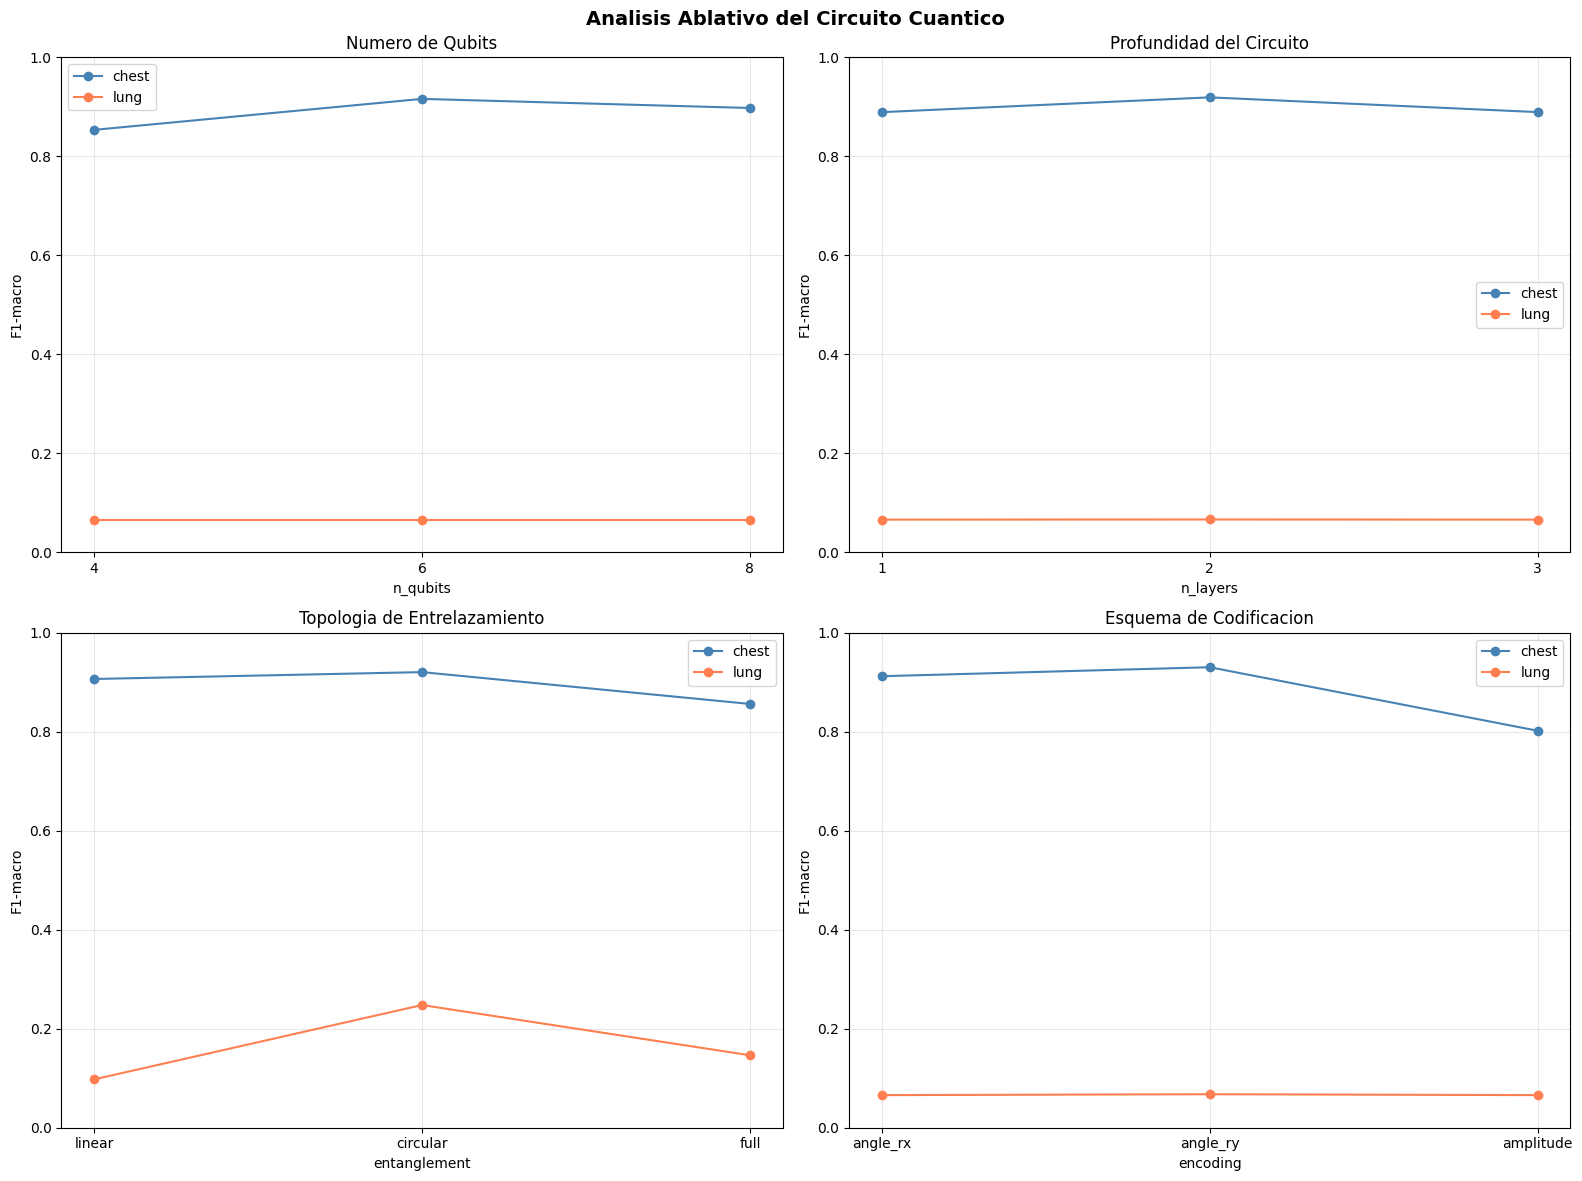

In [9]:
fig,axes=plt.subplots(2,2,figsize=(16,12))
fig.suptitle('Analisis Ablativo del Circuito Cuantico',fontsize=14,fontweight='bold')

configs=[
    (axes[0,0],df_qubits,'n_qubits','Numero de Qubits'),
    (axes[0,1],df_depth,'n_layers','Profundidad del Circuito'),
    (axes[1,0],df_ent,'entanglement','Topologia de Entrelazamiento'),
    (axes[1,1],df_enc,'encoding','Esquema de Codificacion'),
]

for ax,df,xcol,title in configs:
    if df is not None and not df.empty:
        for ds,color in [('chest','steelblue'),('lung','coral')]:
            sub=df[df['dataset']==ds]
            if not sub.empty:
                ax.plot(sub[xcol].astype(str),sub['F1-macro'],marker='o',label=ds,color=color)
        ax.set_title(title);ax.set_xlabel(xcol);ax.set_ylabel('F1-macro')
        ax.set_ylim(0,1);ax.legend();ax.grid(True,alpha=0.3)

plt.tight_layout();plt.show()


## 9 · Guardar resultados ablativo

In [10]:
ablativo_summary={
    'qubits': df_qubits.to_dict('records'),
    'profundidad': df_depth.to_dict('records'),
    'entrelazamiento': df_ent.to_dict('records'),
    'encoding': df_enc.to_dict('records'),
}
out=BASE_DIR/'resultados_ablativo.json'
with open(out,'w') as f: json.dump(ablativo_summary,f,indent=2,default=str)
print('Guardado:',out)
print('\nCSVs generados:')
for f in ['ablativo_qubits.csv','ablativo_profundidad.csv','ablativo_entrelazamiento.csv','ablativo_encoding.csv']:
    print(' ',BASE_DIR/f)


Guardado: D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\resultados_ablativo.json

CSVs generados:
  D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\ablativo_qubits.csv
  D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\ablativo_profundidad.csv
  D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\ablativo_entrelazamiento.csv
  D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\ablativo_encoding.csv
